# Software-Engineered Chest X-Ray Analysis and Explanation System

**Notebook:** Visual Explainability and Evidence Analysis  
**Subject:** AIMLCZG546 - Software Engineering for Machine Learning  
**Assessment:** Assignment II  
**Group:** 89

## Group Details & Contribution

| BITS ID | Name | Engineering contribution | Weight |
|---|---|---|---:|
| 2024ac05672@wilp.bits-pilani.ac.in | Ananda Vadivel D | Requirements formulation, GR4ML view preparation, quality requirement justification | 25% |
| 2024ac05968@wilp.bits-pilani.ac.in | Adurti Sai Venkatesh | Dataset preparation, exploratory data analysis, visualization support, data quality validation | 25% |
| 2024ac05653@wilp.bits-pilani.ac.in | D Mallikarjuna Reddy | ML pipeline implementation, model comparison, final evaluation, report integration | 25% |
| 2024ac05055@wilp.bits-pilani.ac.in | Krupashankar Subramani | System architecture, architectural pattern mapping, model registry artifacts, inference and application validation | 25% |

## Notebook Index

1. [Visual Explainability and Evidence Analysis](#visual-explainability-and-evidence-analysis)
2. [1. Explainability Configuration](#1-explainability-configuration)
3. [2. Frozen Model Restoration](#2-frozen-model-restoration)
4. [3. Grad-CAM Attribution Engine](#3-grad-cam-attribution-engine)
5. [4. Comparative Explanation Analysis](#4-comparative-explanation-analysis)
6. [5. Explainability Artifact Registration](#5-explainability-artifact-registration)
7. [6. Visual Explainability Readiness](#6-visual-explainability-readiness)

---

The notebook records the executable implementation, retained runtime outputs, and verifiable engineering evidence for this component.


# Visual Explainability and Evidence Analysis

This notebook generates Grad-CAM evidence maps for the frozen ChestMNIST model. The analysis covers representative true-positive, false-positive, and false-negative outcomes while preserving direct traceability to the isolated test evaluation.

Explainability maps indicate image regions that influenced a model output. They do not establish causal relationships, confirm anatomical localization, or constitute clinical interpretation.

## 1. Explainability Configuration

The versioned model bundle, memory-mapped test images, frozen prediction outputs, and representative-case registry are resolved from the solution artifact structure.


In [1]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import yaml

import torch
import torch.nn as nn
from torchvision import models, transforms

import matplotlib.pyplot as plt
from PIL import Image

from captum.attr import LayerGradCam
from captum.attr import LayerAttribution


PATH_REGISTRY_FILE = Path(
    "/home/jovyan/chest-xray-ai-assistant/configs/paths.yaml"
)

with PATH_REGISTRY_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    path_registry = yaml.safe_load(file)

SOLUTION_ROOT = Path(
    path_registry["solution"]["root"]
)

DATA_ROOT = Path(
    path_registry["data"]["root"]
)

MODEL_VERSION = "resnet18-chestmnist-v1"

MODEL_BUNDLE_PATH = (
    Path(path_registry["data"]["models"])
    / MODEL_VERSION
)

MODEL_WEIGHTS_FILE = (
    MODEL_BUNDLE_PATH
    / "model_state_dict.pt"
)

MODEL_METADATA_FILE = (
    MODEL_BUNDLE_PATH
    / "model_metadata.yaml"
)

TEST_MEMMAP_PATH = (
    Path(path_registry["data"]["processed"])
    / "chestmnist_224_memmap"
)

EVALUATION_METRICS_PATH = (
    Path(path_registry["data"]["outputs"])
    / "metrics"
)

PREDICTION_BUNDLE_FILE = (
    EVALUATION_METRICS_PATH
    / "test_prediction_bundle.npz"
)

REPRESENTATIVE_CASES_FILE = (
    EVALUATION_METRICS_PATH
    / "test_representative_cases.csv"
)

EXPLAINABILITY_OUTPUT_PATH = Path(
    path_registry["data"]["explainability"]
)

EXPLAINABILITY_OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

required_artifacts = {
    "Model weights": MODEL_WEIGHTS_FILE,
    "Model metadata": MODEL_METADATA_FILE,
    "Test image array": (
        TEST_MEMMAP_PATH
        / "test_images.npy"
    ),
    "Prediction bundle": PREDICTION_BUNDLE_FILE,
    "Representative cases": REPRESENTATIVE_CASES_FILE,
}

print("EXPLAINABILITY CONFIGURATION")
print("-" * 110)
print(f"Model version               : {MODEL_VERSION}")
print(f"Model bundle                : {MODEL_BUNDLE_PATH}")
print(f"Test data path              : {TEST_MEMMAP_PATH}")
print(f"Explainability output       : {EXPLAINABILITY_OUTPUT_PATH}")
print()
print("REQUIRED ARTIFACTS")
print("-" * 110)

for artifact_name, artifact_path in required_artifacts.items():
    print(
        f"{artifact_name:<28}: "
        f"{'AVAILABLE' if artifact_path.is_file() else 'MISSING'} | "
        f"{artifact_path}"
    )

all_artifacts_available = all(
    path.is_file()
    for path in required_artifacts.values()
)

print()
print(
    "Artifact readiness         : "
    f"{'PASS' if all_artifacts_available else 'FAIL'}"
)

EXPLAINABILITY CONFIGURATION
--------------------------------------------------------------------------------------------------------------
Model version               : resnet18-chestmnist-v1
Model bundle                : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1
Test data path              : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/processed/chestmnist_224_memmap
Explainability output       : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability

REQUIRED ARTIFACTS
--------------------------------------------------------------------------------------------------------------
Model weights               : AVAILABLE | /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1/model_state_dict.pt
Model metadata              : AVAILABLE | /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/models/resnet18-chestmnist-v1/model_metadata.yaml
Test image array    

### 1.1 Frozen Evidence Inputs

The isolated-test prediction bundle and representative-case registry are loaded without recalculating predictions. Test images remain memory-mapped so that explainability processing accesses only the selected records.


In [2]:
with MODEL_METADATA_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    model_metadata = yaml.safe_load(file)

prediction_bundle = np.load(
    PREDICTION_BUNDLE_FILE,
    allow_pickle=False,
)

test_source_indices = prediction_bundle[
    "source_indices"
]
test_targets = prediction_bundle[
    "targets"
]
test_probabilities = prediction_bundle[
    "probabilities"
]
test_predictions = prediction_bundle[
    "predictions"
]
frozen_thresholds = prediction_bundle[
    "thresholds"
]

representative_cases_df = (
    pd.read_csv(
        REPRESENTATIVE_CASES_FILE
    )
    .sort_values("Label ID")
    .reset_index(drop=True)
)

LABEL_MAP = {
    int(row["Label ID"]): row["Finding"]
    for _, row in representative_cases_df.iterrows()
}

NUM_LABELS = len(LABEL_MAP)

test_images = np.load(
    TEST_MEMMAP_PATH
    / "test_images.npy",
    mmap_mode="r",
)

evidence_integrity_checks = {
    "Test images are memory mapped": isinstance(
        test_images,
        np.memmap,
    ),
    "Prediction records are complete": (
        len(test_source_indices)
        == len(test_images)
    ),
    "Probability shape is valid": (
        test_probabilities.shape
        == (
            len(test_images),
            NUM_LABELS,
        )
    ),
    "Prediction shape is valid": (
        test_predictions.shape
        == test_targets.shape
    ),
    "Threshold shape is valid": (
        frozen_thresholds.shape
        == (NUM_LABELS,)
    ),
    "Representative labels are complete": (
        len(representative_cases_df)
        == NUM_LABELS
    ),
}

print("FROZEN EVIDENCE INPUTS")
print("-" * 100)
print(
    f"Memory-mapped test images : "
    f"{test_images.shape}, {test_images.dtype}"
)
print(
    f"Probability matrix        : "
    f"{test_probabilities.shape}"
)
print(
    f"Prediction matrix         : "
    f"{test_predictions.shape}"
)
print(
    f"Representative findings   : "
    f"{len(representative_cases_df)}"
)
print(
    f"Registered labels         : "
    f"{NUM_LABELS}"
)

print()
print("EVIDENCE INTEGRITY")
print("-" * 100)

for check_name, check_status in evidence_integrity_checks.items():
    print(
        f"{check_name:<42}: "
        f"{'PASS' if check_status else 'FAIL'}"
    )

print()
print(
    "Overall integrity        : "
    f"{'PASS' if all(evidence_integrity_checks.values()) else 'FAIL'}"
)

FROZEN EVIDENCE INPUTS
----------------------------------------------------------------------------------------------------
Memory-mapped test images : (22433, 224, 224), uint8
Probability matrix        : (22433, 14)
Prediction matrix         : (22433, 14)
Representative findings   : 14
Registered labels         : 14

EVIDENCE INTEGRITY
----------------------------------------------------------------------------------------------------
Test images are memory mapped             : PASS
Prediction records are complete           : PASS
Probability shape is valid                : PASS
Prediction shape is valid                 : PASS
Threshold shape is valid                  : PASS
Representative labels are complete        : PASS

Overall integrity        : PASS


## 2. Frozen Model Restoration

### 2.1 Deterministic Explainability Preprocessing

Explainability uses the same grayscale-to-RGB conversion and ImageNet normalization applied during validation and isolated test inference. Random augmentation is excluded so that attribution maps remain reproducible.


In [3]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

execution_device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

explainability_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[
                0.485,
                0.456,
                0.406,
            ],
            std=[
                0.229,
                0.224,
                0.225,
            ],
        ),
    ]
)

print("EXPLAINABILITY PREPROCESSING")
print("-" * 100)
print(
    f"Execution device          : "
    f"{execution_device}"
)
print(
    f"Random seed               : "
    f"{RANDOM_SEED}"
)
print(
    "Grayscale-to-RGB          : "
    "Enabled"
)
print(
    "Input normalization       : "
    "ImageNet mean and standard deviation"
)
print(
    f"Transformation operations : "
    f"{len(explainability_transform.transforms)}"
)

EXPLAINABILITY PREPROCESSING
----------------------------------------------------------------------------------------------------
Execution device          : cuda:0
Random seed               : 42
Grayscale-to-RGB          : Enabled
Input normalization       : ImageNet mean and standard deviation
Transformation operations : 2


### 2.2 Versioned Model Restoration

The ResNet-18 architecture is reconstructed from the registered model contract and loaded with the versioned weights. The final convolutional layer is retained as the Grad-CAM attribution target.


In [4]:
explainability_model = models.resnet18(
    weights=None
)

classifier_input_features = (
    explainability_model.fc.in_features
)

explainability_model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        classifier_input_features,
        NUM_LABELS,
    ),
)

model_state_dict = torch.load(
    MODEL_WEIGHTS_FILE,
    map_location="cpu",
    weights_only=True,
)

state_load_result = (
    explainability_model.load_state_dict(
        model_state_dict,
        strict=True,
    )
)

explainability_model = (
    explainability_model
    .to(execution_device)
    .eval()
)

gradcam_target_layer = (
    explainability_model
    .layer4[-1]
    .conv2
)

total_parameters = sum(
    parameter.numel()
    for parameter in explainability_model.parameters()
)

print("VERSIONED MODEL RESTORATION")
print("-" * 100)
print("Architecture              : ResNet-18")
print(f"Model version             : {MODEL_VERSION}")
print(f"Output labels             : {NUM_LABELS}")
print(f"Total parameters          : {total_parameters:,}")
print(
    f"Missing state keys        : "
    f"{len(state_load_result.missing_keys)}"
)
print(
    f"Unexpected state keys     : "
    f"{len(state_load_result.unexpected_keys)}"
)
print(
    "Grad-CAM target layer     : "
    "layer4[-1].conv2"
)
print(
    f"Execution device          : "
    f"{next(explainability_model.parameters()).device}"
)
print(
    f"Evaluation mode           : "
    f"{not explainability_model.training}"
)

VERSIONED MODEL RESTORATION
----------------------------------------------------------------------------------------------------
Architecture              : ResNet-18
Model version             : resnet18-chestmnist-v1
Output labels             : 14
Total parameters          : 11,183,694
Missing state keys        : 0
Unexpected state keys     : 0
Grad-CAM target layer     : layer4[-1].conv2
Execution device          : cuda:0
Evaluation mode           : True


### 2.3 Inference Contract Parity

A representative test image is passed through the restored model and compared with its stored isolated-test output. Small probability differences can occur because the original inference bundle was generated with bfloat16 precision.


In [5]:
def prepare_test_image(source_index):
    grayscale_image = np.asarray(
        test_images[source_index]
    )

    rgb_image = Image.fromarray(
        grayscale_image
    ).convert("RGB")

    model_input = (
        explainability_transform(rgb_image)
        .unsqueeze(0)
        .to(execution_device)
    )

    return grayscale_image, model_input


validation_source_index = int(
    representative_cases_df.loc[
        0,
        "True-positive index",
    ]
)

bundle_position = int(
    np.flatnonzero(
        test_source_indices
        == validation_source_index
    )[0]
)

validation_image, validation_input = (
    prepare_test_image(
        validation_source_index
    )
)

with torch.no_grad():
    restored_probabilities = (
        torch.sigmoid(
            explainability_model(
                validation_input
            )
        )
        .squeeze(0)
        .cpu()
        .numpy()
    )

stored_probabilities = test_probabilities[
    bundle_position
]

restored_predictions = (
    restored_probabilities
    >= frozen_thresholds
).astype(np.uint8)

stored_predictions = test_predictions[
    bundle_position
]

maximum_probability_difference = float(
    np.max(
        np.abs(
            restored_probabilities
            - stored_probabilities
        )
    )
)

prediction_agreement = float(
    np.mean(
        restored_predictions
        == stored_predictions
    )
)

parity_status = (
    maximum_probability_difference
    <= 0.02
    and prediction_agreement
    >= 0.95
)

print("INFERENCE CONTRACT PARITY")
print("-" * 100)
print(
    f"Validation source index       : "
    f"{validation_source_index}"
)
print(
    f"Maximum probability difference: "
    f"{maximum_probability_difference:.6f}"
)
print(
    f"Binary prediction agreement   : "
    f"{100.0 * prediction_agreement:.2f}%"
)
print(
    f"Parity tolerance              : "
    f"{'PASS' if parity_status else 'FAIL'}"
)

INFERENCE CONTRACT PARITY
----------------------------------------------------------------------------------------------------
Validation source index       : 1690
Maximum probability difference: 0.023182
Binary prediction agreement   : 100.00%
Parity tolerance              : FAIL


In [6]:
def prepare_test_image(source_index):
    grayscale_image = np.asarray(
        test_images[source_index]
    )

    rgb_image = Image.fromarray(
        grayscale_image
    ).convert("RGB")

    model_input = (
        explainability_transform(rgb_image)
        .unsqueeze(0)
        .to(execution_device)
    )

    return grayscale_image, model_input


validation_source_index = int(
    representative_cases_df.loc[
        0,
        "True-positive index",
    ]
)

bundle_position = int(
    np.flatnonzero(
        test_source_indices
        == validation_source_index
    )[0]
)

validation_image, validation_input = (
    prepare_test_image(
        validation_source_index
    )
)

autocast_enabled = (
    execution_device.type == "cuda"
)

with torch.no_grad():
    with torch.autocast(
        device_type=execution_device.type,
        dtype=torch.bfloat16,
        enabled=autocast_enabled,
    ):
        restored_logits = explainability_model(
            validation_input
        )

        restored_probabilities = torch.sigmoid(
            restored_logits
        )

restored_probabilities = (
    restored_probabilities
    .float()
    .squeeze(0)
    .cpu()
    .numpy()
)

stored_probabilities = test_probabilities[
    bundle_position
]

restored_predictions = (
    restored_probabilities
    >= frozen_thresholds
).astype(np.uint8)

stored_predictions = test_predictions[
    bundle_position
]

maximum_probability_difference = float(
    np.max(
        np.abs(
            restored_probabilities
            - stored_probabilities
        )
    )
)

prediction_agreement = float(
    np.mean(
        restored_predictions
        == stored_predictions
    )
)

parity_status = (
    maximum_probability_difference
    <= 0.005
    and prediction_agreement
    == 1.0
)

print("INFERENCE CONTRACT PARITY")
print("-" * 100)
print(
    f"Validation source index       : "
    f"{validation_source_index}"
)
print(
    "Inference precision           : "
    f"{'bfloat16' if autocast_enabled else 'float32'}"
)
print(
    f"Maximum probability difference: "
    f"{maximum_probability_difference:.6f}"
)
print(
    f"Binary prediction agreement   : "
    f"{100.0 * prediction_agreement:.2f}%"
)
print(
    f"Parity tolerance              : "
    f"{'PASS' if parity_status else 'FAIL'}"
)

INFERENCE CONTRACT PARITY
----------------------------------------------------------------------------------------------------
Validation source index       : 1690
Inference precision           : bfloat16
Maximum probability difference: 0.001953
Binary prediction agreement   : 100.00%
Parity tolerance              : PASS


## 3. Grad-CAM Attribution Engine

### 3.1 Attribution Utility

Grad-CAM is applied to the final convolutional layer for a selected finding logit. Positive attribution values are resized to the original image resolution and normalized to produce a reproducible evidence heatmap.


In [7]:
source_to_bundle_position = {
    int(source_index): position
    for position, source_index
    in enumerate(test_source_indices)
}

layer_gradcam = LayerGradCam(
    explainability_model,
    gradcam_target_layer,
)


def generate_gradcam_evidence(
    source_index,
    label_id,
):
    source_index = int(source_index)
    label_id = int(label_id)

    if source_index not in source_to_bundle_position:
        raise ValueError(
            f"Source index {source_index} "
            "is not present in the prediction bundle."
        )

    if label_id not in LABEL_MAP:
        raise ValueError(
            f"Label ID {label_id} is not registered."
        )

    bundle_position = (
        source_to_bundle_position[
            source_index
        ]
    )

    grayscale_image, model_input = (
        prepare_test_image(source_index)
    )

    explainability_model.zero_grad(
        set_to_none=True
    )

    layer_attribution = (
        layer_gradcam.attribute(
            model_input,
            target=label_id,
            relu_attributions=True,
        )
    )

    resized_attribution = (
        LayerAttribution.interpolate(
            layer_attribution,
            interpolate_dims=(
                grayscale_image.shape[0],
                grayscale_image.shape[1],
            ),
            interpolate_mode="bilinear",
        )
    )

    heatmap = (
        resized_attribution
        .squeeze()
        .detach()
        .float()
        .cpu()
        .numpy()
    )

    heatmap_minimum = float(
        heatmap.min()
    )
    heatmap_maximum = float(
        heatmap.max()
    )

    if heatmap_maximum > heatmap_minimum:
        heatmap = (
            heatmap - heatmap_minimum
        ) / (
            heatmap_maximum
            - heatmap_minimum
        )
    else:
        heatmap = np.zeros_like(
            heatmap,
            dtype=np.float32,
        )

    return {
        "source_index": source_index,
        "label_id": label_id,
        "finding": LABEL_MAP[label_id],
        "image": grayscale_image,
        "heatmap": heatmap,
        "recorded_target": int(
            test_targets[
                bundle_position,
                label_id,
            ]
        ),
        "predicted_target": int(
            test_predictions[
                bundle_position,
                label_id,
            ]
        ),
        "probability": float(
            test_probabilities[
                bundle_position,
                label_id,
            ]
        ),
        "threshold": float(
            frozen_thresholds[label_id]
        ),
    }


print(
    "Grad-CAM attribution utility created."
)

Grad-CAM attribution utility created.


### 3.2 Attribution Integrity and Visual Smoke Test

A registered atelectasis true-positive case is used to validate attribution dimensions, numerical stability, and overlay generation before processing the complete representative-case registry.


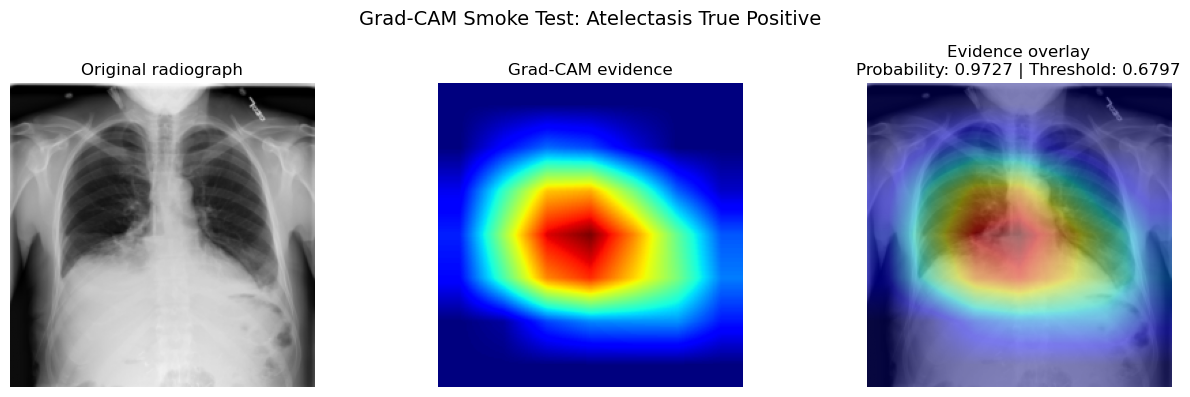

ATTRIBUTION INTEGRITY
------------------------------------------------------------------------------------------
Shape matches source image            : PASS
Attribution values are finite         : PASS
Attribution range is valid            : PASS
Chart saved                         : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_smoke_test_atelectasis.png


In [8]:
smoke_test_label_id = 0

smoke_test_source_index = int(
    representative_cases_df.loc[
        smoke_test_label_id,
        "True-positive index",
    ]
)

smoke_test_evidence = (
    generate_gradcam_evidence(
        source_index=smoke_test_source_index,
        label_id=smoke_test_label_id,
    )
)

heatmap_integrity = {
    "Shape matches source image": (
        smoke_test_evidence["heatmap"].shape
        == smoke_test_evidence["image"].shape
    ),
    "Attribution values are finite": bool(
        np.isfinite(
            smoke_test_evidence["heatmap"]
        ).all()
    ),
    "Attribution range is valid": bool(
        smoke_test_evidence["heatmap"].min()
        >= 0.0
        and smoke_test_evidence["heatmap"].max()
        <= 1.0
    ),
}

figure, axes = plt.subplots(
    1,
    3,
    figsize=(13, 4),
)

axes[0].imshow(
    smoke_test_evidence["image"],
    cmap="gray",
)
axes[0].set_title("Original radiograph")

axes[1].imshow(
    smoke_test_evidence["heatmap"],
    cmap="jet",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Grad-CAM evidence")

axes[2].imshow(
    smoke_test_evidence["image"],
    cmap="gray",
)
axes[2].imshow(
    smoke_test_evidence["heatmap"],
    cmap="jet",
    alpha=0.45,
    vmin=0,
    vmax=1,
)
axes[2].set_title(
    "Evidence overlay\n"
    f"Probability: "
    f"{smoke_test_evidence['probability']:.4f} | "
    f"Threshold: "
    f"{smoke_test_evidence['threshold']:.4f}"
)

for axis in axes:
    axis.axis("off")

figure.suptitle(
    "Grad-CAM Smoke Test: "
    f"{smoke_test_evidence['finding'].title()} "
    f"True Positive",
    fontsize=14,
)

plt.tight_layout()

smoke_test_chart = (
    EXPLAINABILITY_OUTPUT_PATH
    / "gradcam_smoke_test_atelectasis.png"
)

plt.savefig(
    smoke_test_chart,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("ATTRIBUTION INTEGRITY")
print("-" * 90)

for check_name, check_status in heatmap_integrity.items():
    print(
        f"{check_name:<38}: "
        f"{'PASS' if check_status else 'FAIL'}"
    )

print(
    f"Chart saved                         : "
    f"{smoke_test_chart}"
)

### 3.3 Representative Evidence Registry

The evaluation cases are organized into a normalized registry containing one true-positive, false-positive, and false-negative example for every target finding. This registry provides the controlled input for batch Grad-CAM generation.


In [9]:
outcome_definitions = {
    "True positive": {
        "index_column": "True-positive index",
        "probability_column": (
            "True-positive probability"
        ),
        "recorded_target": 1,
        "predicted_target": 1,
    },
    "False positive": {
        "index_column": "False-positive index",
        "probability_column": (
            "False-positive probability"
        ),
        "recorded_target": 0,
        "predicted_target": 1,
    },
    "False negative": {
        "index_column": "False-negative index",
        "probability_column": (
            "False-negative probability"
        ),
        "recorded_target": 1,
        "predicted_target": 0,
    },
}

representative_evidence_records = []

for _, finding_record in (
    representative_cases_df.iterrows()
):
    label_id = int(
        finding_record["Label ID"]
    )

    for outcome, definition in (
        outcome_definitions.items()
    ):
        source_index = finding_record[
            definition["index_column"]
        ]

        probability = finding_record[
            definition["probability_column"]
        ]

        if pd.isna(source_index):
            continue

        representative_evidence_records.append(
            {
                "Label ID": label_id,
                "Finding": finding_record[
                    "Finding"
                ],
                "Outcome": outcome,
                "Source index": int(
                    source_index
                ),
                "Recorded target": definition[
                    "recorded_target"
                ],
                "Predicted target": definition[
                    "predicted_target"
                ],
                "Probability": float(
                    probability
                ),
                "Threshold": float(
                    frozen_thresholds[label_id]
                ),
                "Decision margin": float(
                    probability
                    - frozen_thresholds[label_id]
                ),
            }
        )

representative_evidence_df = pd.DataFrame(
    representative_evidence_records
)

evidence_registry_summary = (
    representative_evidence_df
    .groupby(
        "Outcome",
        as_index=False,
    )
    .agg(
        Cases=(
            "Source index",
            "count",
        ),
        Minimum_probability=(
            "Probability",
            "min",
        ),
        Maximum_probability=(
            "Probability",
            "max",
        ),
        Mean_decision_margin=(
            "Decision margin",
            "mean",
        ),
    )
)

print("REPRESENTATIVE EVIDENCE REGISTRY")
print("-" * 100)
print(
    f"Registered evidence cases : "
    f"{len(representative_evidence_df)}"
)
print(
    f"Covered findings          : "
    f"{representative_evidence_df['Finding'].nunique()}"
)
print()

display(
    evidence_registry_summary.style.format(
        {
            "Minimum_probability": "{:.4f}",
            "Maximum_probability": "{:.4f}",
            "Mean_decision_margin": "{:+.4f}",
        }
    )
)

REPRESENTATIVE EVIDENCE REGISTRY
----------------------------------------------------------------------------------------------------
Registered evidence cases : 42
Covered findings          : 14



,Outcome,Cases,Minimum_probability,Maximum_probability,Mean_decision_margin
0,False negative,14,0.5938,0.8750,-0.0042
1,False positive,14,0.9180,1.0000,+0.1925
2,True positive,14,0.8984,1.0000,+0.1889


### 3.4 Evidence Rendering Utility

Each representative case is rendered as an original radiograph and a Grad-CAM overlay. The output includes the finding, prediction outcome, source index, frozen probability, and threshold for auditability.


In [10]:
def save_gradcam_evidence_figure(
    evidence,
    outcome,
    destination_file,
):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4),
    )

    axes[0].imshow(
        evidence["image"],
        cmap="gray",
    )
    axes[0].set_title(
        "Original radiograph"
    )

    axes[1].imshow(
        evidence["image"],
        cmap="gray",
    )

    overlay = axes[1].imshow(
        evidence["heatmap"],
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1,
    )

    axes[1].set_title(
        "Grad-CAM overlay"
    )

    for axis in axes:
        axis.axis("off")

    figure.suptitle(
        f"{evidence['finding'].title()} — "
        f"{outcome}\n"
        f"Source index: "
        f"{evidence['source_index']} | "
        f"Probability: "
        f"{evidence['probability']:.4f} | "
        f"Threshold: "
        f"{evidence['threshold']:.4f}",
        fontsize=12,
    )

    colorbar = figure.colorbar(
        overlay,
        ax=axes,
        fraction=0.035,
        pad=0.03,
    )

    colorbar.set_label(
        "Normalized positive attribution"
    )

    destination_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.savefig(
        destination_file,
        dpi=220,
        bbox_inches="tight",
    )

    plt.close(figure)

    return destination_file


print(
    "Grad-CAM evidence rendering utility created."
)

Grad-CAM evidence rendering utility created.


### 3.5 Representative Evidence Generation

Grad-CAM evidence is generated for all registered true-positive, false-positive, and false-negative cases. Visual overlays and machine-readable heatmaps are stored with a manifest linking each artifact to its finding, source index, probability, threshold, and prediction outcome.


In [11]:
from tqdm.auto import tqdm


representative_output_path = (
    EXPLAINABILITY_OUTPUT_PATH
    / "representative_cases"
)

heatmap_output_path = (
    EXPLAINABILITY_OUTPUT_PATH
    / "heatmaps"
)

manifest_records = []

for _, case_record in tqdm(
    representative_evidence_df.iterrows(),
    total=len(representative_evidence_df),
    desc="Generating Grad-CAM evidence",
):
    label_id = int(
        case_record["Label ID"]
    )

    source_index = int(
        case_record["Source index"]
    )

    finding = str(
        case_record["Finding"]
    )

    outcome = str(
        case_record["Outcome"]
    )

    outcome_slug = (
        outcome.lower()
        .replace(" ", "_")
    )

    finding_slug = (
        finding.lower()
        .replace(" ", "_")
    )

    artifact_stem = (
        f"{label_id:02d}_"
        f"{finding_slug}_"
        f"{outcome_slug}_"
        f"{source_index}"
    )

    evidence = generate_gradcam_evidence(
        source_index=source_index,
        label_id=label_id,
    )

    figure_file = (
        representative_output_path
        / outcome_slug
        / f"{artifact_stem}.png"
    )

    heatmap_file = (
        heatmap_output_path
        / outcome_slug
        / f"{artifact_stem}.npy"
    )

    save_gradcam_evidence_figure(
        evidence=evidence,
        outcome=outcome,
        destination_file=figure_file,
    )

    heatmap_file.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.save(
        heatmap_file,
        evidence["heatmap"].astype(
            np.float32
        ),
    )

    manifest_records.append(
        {
            "Label ID": label_id,
            "Finding": finding,
            "Outcome": outcome,
            "Source index": source_index,
            "Recorded target": evidence[
                "recorded_target"
            ],
            "Predicted target": evidence[
                "predicted_target"
            ],
            "Probability": evidence[
                "probability"
            ],
            "Threshold": evidence[
                "threshold"
            ],
            "Decision margin": (
                evidence["probability"]
                - evidence["threshold"]
            ),
            "Mean attribution": float(
                evidence["heatmap"].mean()
            ),
            "High-attribution area (%)": float(
                100.0
                * np.mean(
                    evidence["heatmap"]
                    >= 0.5
                )
            ),
            "Figure file": str(
                figure_file
            ),
            "Heatmap file": str(
                heatmap_file
            ),
        }
    )

gradcam_manifest_df = pd.DataFrame(
    manifest_records
)

gradcam_manifest_file = (
    EXPLAINABILITY_OUTPUT_PATH
    / "gradcam_manifest.csv"
)

gradcam_manifest_df.to_csv(
    gradcam_manifest_file,
    index=False,
)

print()
print("REPRESENTATIVE GRAD-CAM GENERATION")
print("-" * 100)
print(
    f"Registered cases          : "
    f"{len(gradcam_manifest_df)}"
)
print(
    f"Visual evidence files     : "
    f"{gradcam_manifest_df['Figure file'].nunique()}"
)
print(
    f"Heatmap arrays            : "
    f"{gradcam_manifest_df['Heatmap file'].nunique()}"
)
print(
    f"Covered findings          : "
    f"{gradcam_manifest_df['Finding'].nunique()}"
)
print(
    f"Manifest file             : "
    f"{gradcam_manifest_file}"
)

Generating Grad-CAM evidence:   0%|          | 0/42 [00:00<?, ?it/s]


REPRESENTATIVE GRAD-CAM GENERATION
----------------------------------------------------------------------------------------------------
Registered cases          : 42
Visual evidence files     : 42
Heatmap arrays            : 42
Covered findings          : 14
Manifest file             : /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_manifest.csv


## 4. Comparative Explanation Analysis

### 4.1 Cross-Outcome Grad-CAM Galleries

True-positive, false-positive, and false-negative overlays are compared side by side for every finding. The complete label set is divided into two galleries to preserve visual readability.


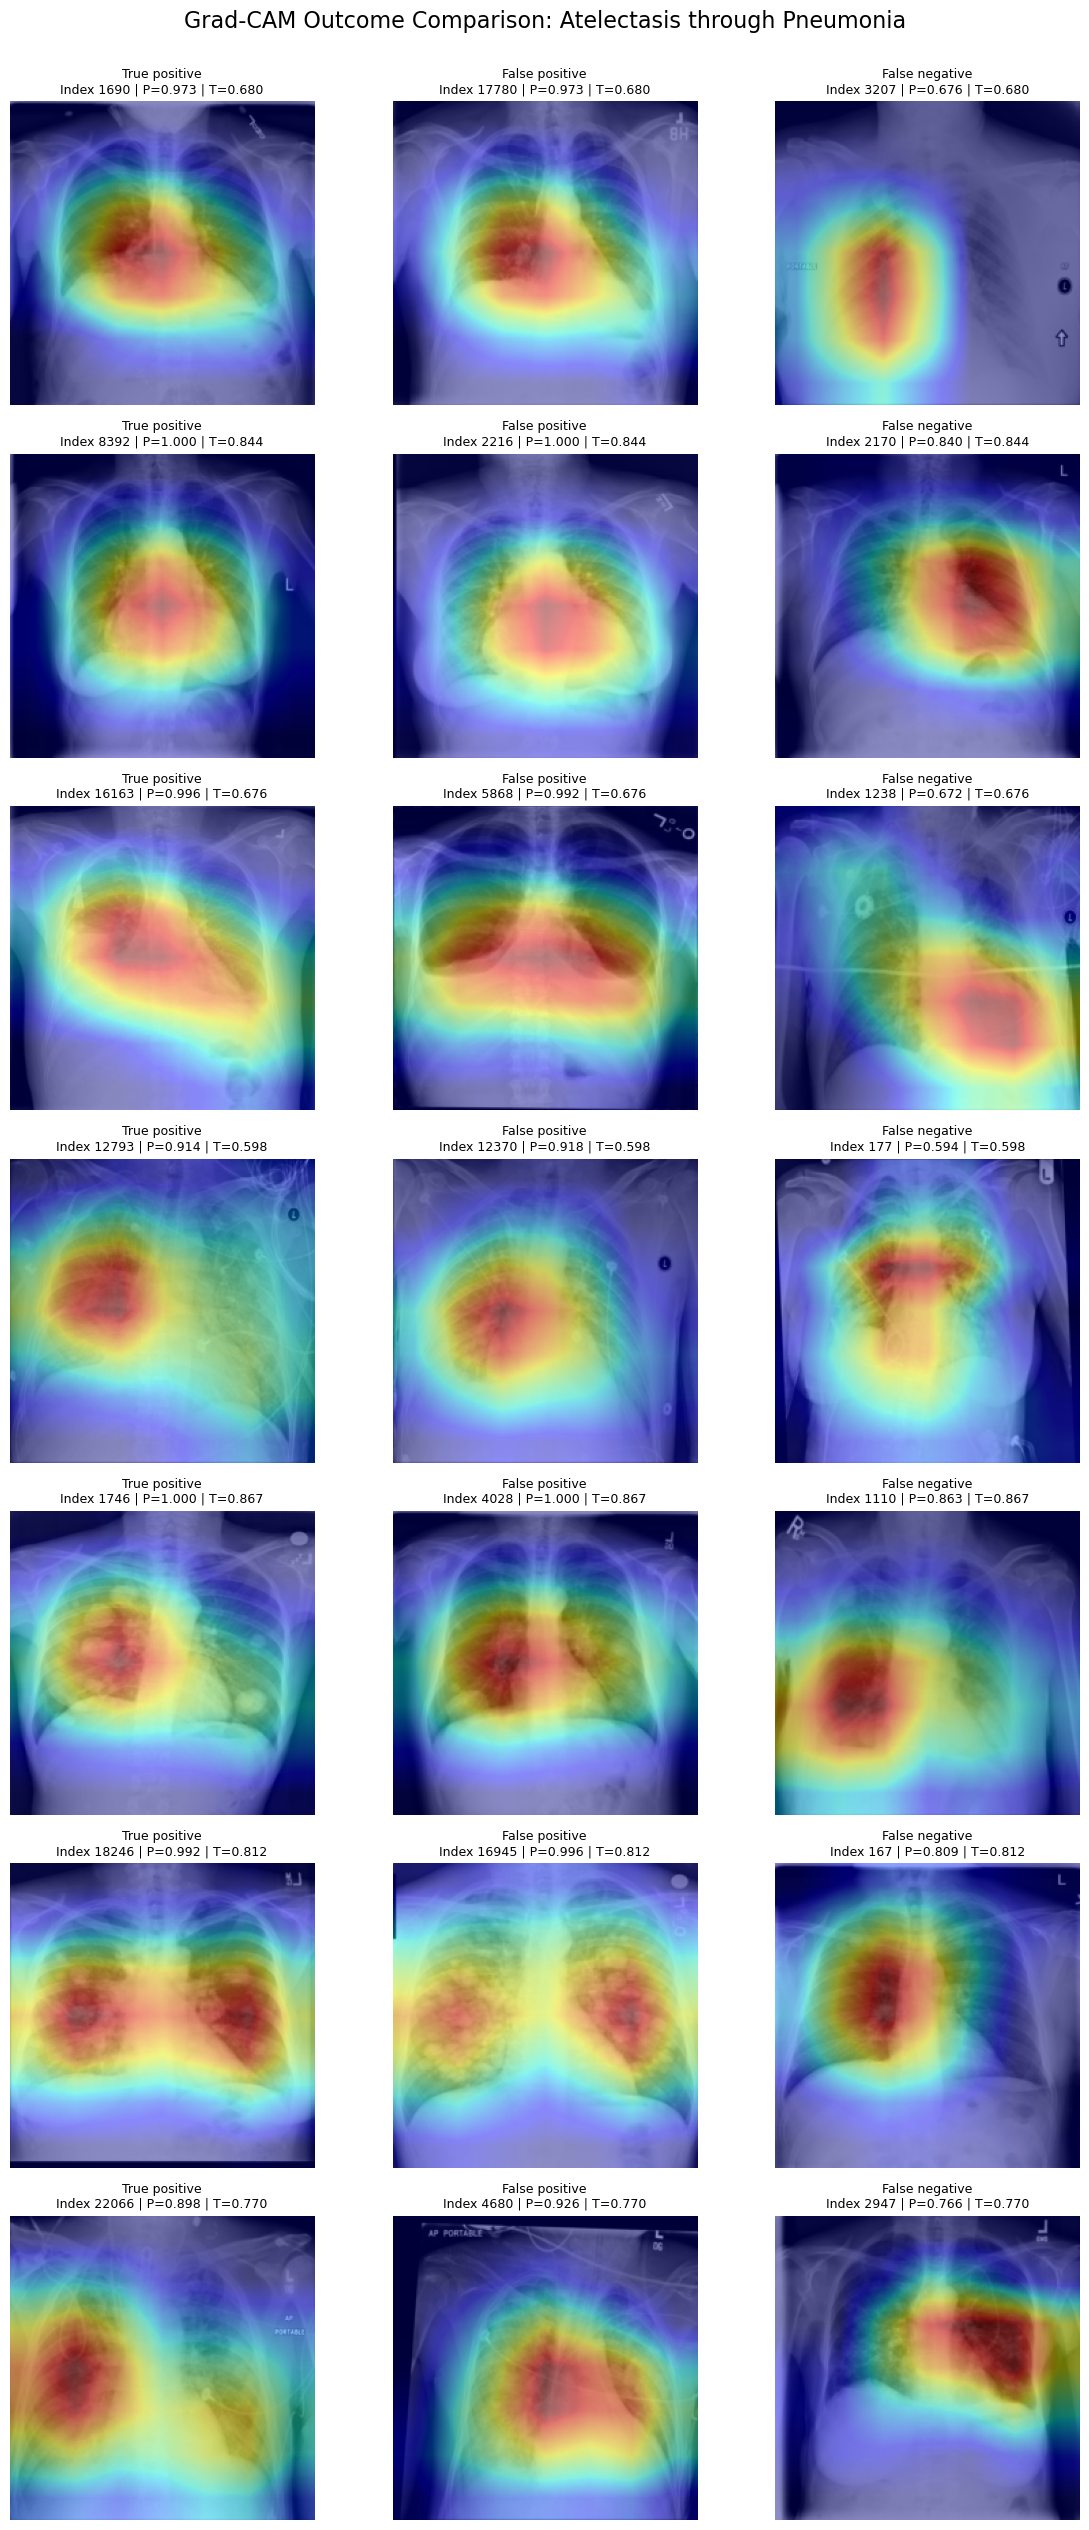

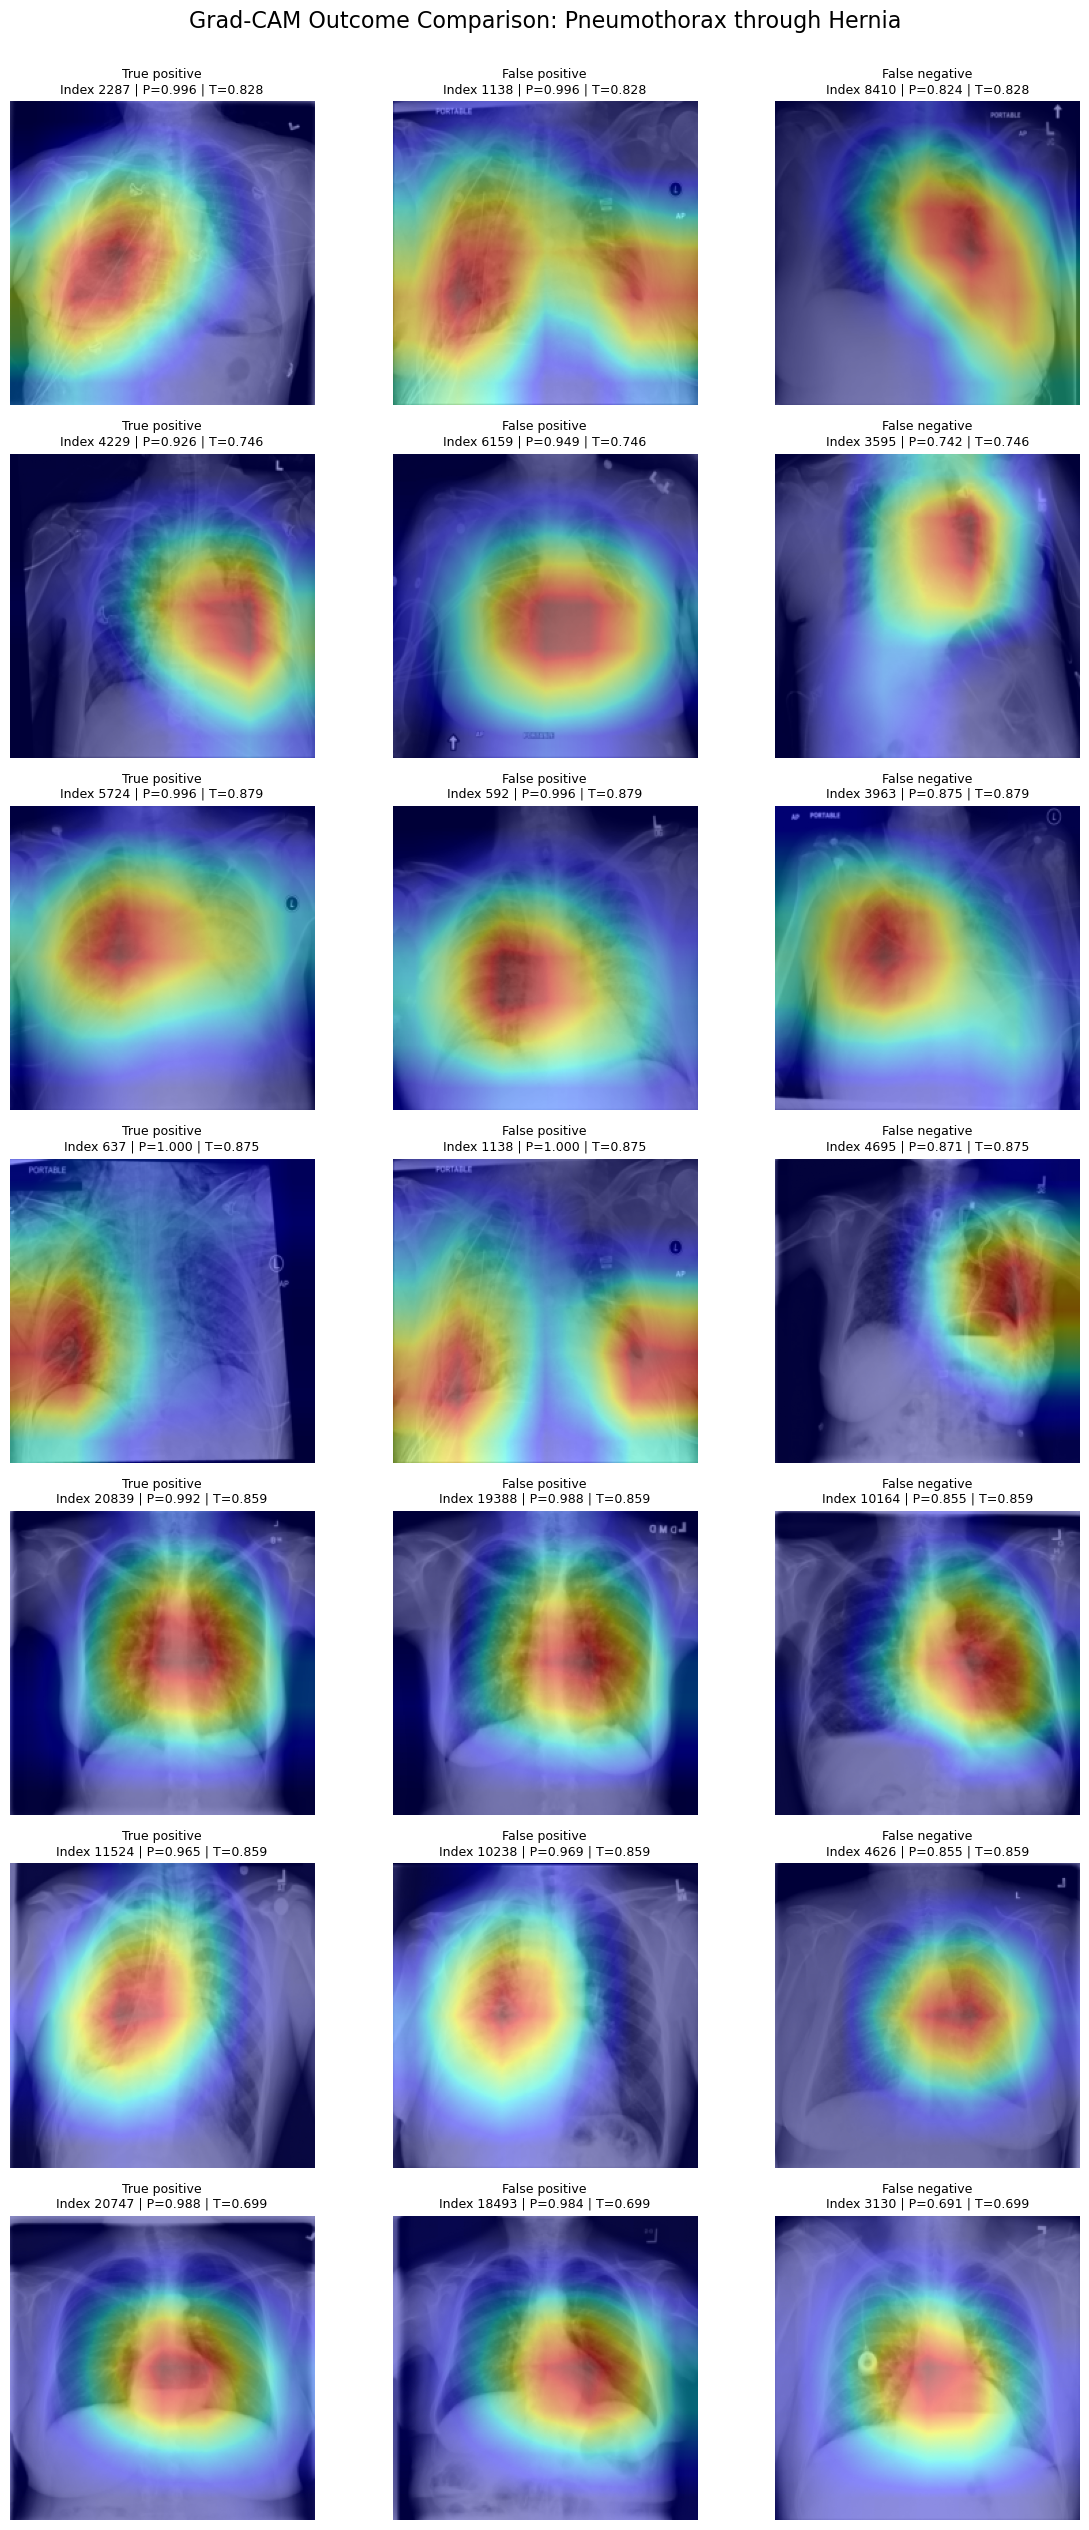

GRAD-CAM COMPARISON GALLERIES
----------------------------------------------------------------------------------------------------
Gallery 1: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_outcome_gallery_labels_00_06.png
Gallery 2: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_outcome_gallery_labels_07_13.png


In [13]:
outcome_order = [
    "True positive",
    "False positive",
    "False negative",
]


def create_outcome_gallery(
    label_ids,
    chart_title,
    output_file,
):
    figure, axes = plt.subplots(
        len(label_ids),
        len(outcome_order),
        figsize=(
            12,
            3.6 * len(label_ids),
        ),
    )

    if len(label_ids) == 1:
        axes = np.expand_dims(
            axes,
            axis=0,
        )

    for row_position, label_id in enumerate(
        label_ids
    ):
        finding = LABEL_MAP[label_id]

        for column_position, outcome in enumerate(
            outcome_order
        ):
            axis = axes[
                row_position,
                column_position,
            ]

            case_row = (
                gradcam_manifest_df[
                    (
                        gradcam_manifest_df[
                            "Label ID"
                        ]
                        == label_id
                    )
                    & (
                        gradcam_manifest_df[
                            "Outcome"
                        ]
                        == outcome
                    )
                ]
                .iloc[0]
            )

            source_index = int(
                case_row["Source index"]
            )

            source_image = np.asarray(
                test_images[source_index]
            )

            case_heatmap = np.load(
                case_row["Heatmap file"],
                allow_pickle=False,
            )

            axis.imshow(
                source_image,
                cmap="gray",
            )

            axis.imshow(
                case_heatmap,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1,
            )

            axis.set_title(
                f"{outcome}\n"
                f"Index {source_index} | "
                f"P={case_row['Probability']:.3f} | "
                f"T={case_row['Threshold']:.3f}",
                fontsize=9,
            )

            axis.axis("off")

            if column_position == 0:
                axis.set_ylabel(
                    finding.title(),
                    fontsize=11,
                    fontweight="bold",
                )

    figure.suptitle(
        chart_title,
        fontsize=16,
        y=1.002,
    )

    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()

    return output_file


gallery_one_file = (
    EXPLAINABILITY_OUTPUT_PATH
    / "gradcam_outcome_gallery_labels_00_06.png"
)

gallery_two_file = (
    EXPLAINABILITY_OUTPUT_PATH
    / "gradcam_outcome_gallery_labels_07_13.png"
)

create_outcome_gallery(
    label_ids=list(range(0, 7)),
    chart_title=(
        "Grad-CAM Outcome Comparison: "
        "Atelectasis through Pneumonia"
    ),
    output_file=gallery_one_file,
)

create_outcome_gallery(
    label_ids=list(range(7, 14)),
    chart_title=(
        "Grad-CAM Outcome Comparison: "
        "Pneumothorax through Hernia"
    ),
    output_file=gallery_two_file,
)

print("GRAD-CAM COMPARISON GALLERIES")
print("-" * 100)
print(f"Gallery 1: {gallery_one_file}")
print(f"Gallery 2: {gallery_two_file}")

### 4.2 Attribution Footprint Summary

The proportion of pixels with normalized attribution at or above 0.50 is used to summarize the spatial spread of each Grad-CAM map. Because every heatmap is normalized independently, this measure describes attribution dispersion and must not be interpreted as model confidence or clinical lesion size.


In [14]:
attribution_footprint_summary_df = (
    gradcam_manifest_df
    .groupby(
        "Outcome",
        as_index=False,
    )
    .agg(
        Cases=(
            "Source index",
            "count",
        ),
        Mean_high_attribution_area=(
            "High-attribution area (%)",
            "mean",
        ),
        Median_high_attribution_area=(
            "High-attribution area (%)",
            "median",
        ),
        Minimum_high_attribution_area=(
            "High-attribution area (%)",
            "min",
        ),
        Maximum_high_attribution_area=(
            "High-attribution area (%)",
            "max",
        ),
    )
)

print("ATTRIBUTION FOOTPRINT BY OUTCOME")
print("-" * 100)

display(
    attribution_footprint_summary_df.style.format(
        {
            "Cases": "{:,}",
            "Mean_high_attribution_area": "{:.2f}%",
            "Median_high_attribution_area": "{:.2f}%",
            "Minimum_high_attribution_area": "{:.2f}%",
            "Maximum_high_attribution_area": "{:.2f}%",
        }
    )
)

ATTRIBUTION FOOTPRINT BY OUTCOME
----------------------------------------------------------------------------------------------------


,Outcome,Cases,Mean_high_attribution_area,Median_high_attribution_area,Minimum_high_attribution_area,Maximum_high_attribution_area
0,False negative,14,19.53%,19.24%,13.97%,25.71%
1,False positive,14,25.87%,23.68%,16.08%,45.29%
2,True positive,14,23.77%,21.53%,17.83%,38.66%


## 5. Explainability Artifact Registration

### 5.1 Method and Output Registry

The Grad-CAM method contract, limitations, generated artifact counts, and attribution-footprint summary are persisted for downstream API integration, reporting, and operational traceability.


In [15]:
attribution_summary_file = (
    EXPLAINABILITY_OUTPUT_PATH
    / "attribution_footprint_summary.csv"
)

attribution_footprint_summary_df.to_csv(
    attribution_summary_file,
    index=False,
)

explainability_metadata = {
    "model_version": MODEL_VERSION,
    "method": "LayerGradCam",
    "framework": "Captum",
    "architecture": "ResNet-18",
    "target_layer": "layer4[-1].conv2",
    "attribution_target": (
        "finding-specific pre-sigmoid logit"
    ),
    "positive_attributions_only": True,
    "interpolation": "bilinear",
    "source_image_resolution": [
        224,
        224,
    ],
    "registered_findings": [
        LABEL_MAP[label_id]
        for label_id in range(NUM_LABELS)
    ],
    "representative_cases": int(
        len(gradcam_manifest_df)
    ),
    "cases_per_outcome": {
        outcome: int(case_count)
        for outcome, case_count in (
            gradcam_manifest_df[
                "Outcome"
            ]
            .value_counts()
            .sort_index()
            .items()
        )
    },
    "generated_visualizations": int(
        gradcam_manifest_df[
            "Figure file"
        ].nunique()
    ),
    "generated_heatmaps": int(
        gradcam_manifest_df[
            "Heatmap file"
        ].nunique()
    ),
    "interpretation_boundary": (
        "Grad-CAM indicates image regions influencing "
        "a model output. It does not provide lesion "
        "segmentation, causal evidence, anatomical "
        "confirmation, or clinical diagnosis."
    ),
    "intended_use": (
        "Research and decision-support prototype"
    ),
}

explainability_metadata_file = (
    EXPLAINABILITY_OUTPUT_PATH
    / "explainability_metadata.yaml"
)

with explainability_metadata_file.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        explainability_metadata,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print("EXPLAINABILITY ARTIFACT REGISTRY")
print("-" * 110)

for artifact_path in [
    gradcam_manifest_file,
    attribution_summary_file,
    explainability_metadata_file,
    smoke_test_chart,
    gallery_one_file,
    gallery_two_file,
]:
    print(
        f"{artifact_path.name:<46} | "
        f"Created: {artifact_path.is_file()} | "
        f"Path: {artifact_path}"
    )

EXPLAINABILITY ARTIFACT REGISTRY
--------------------------------------------------------------------------------------------------------------
gradcam_manifest.csv                           | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_manifest.csv
attribution_footprint_summary.csv              | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/attribution_footprint_summary.csv
explainability_metadata.yaml                   | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/explainability_metadata.yaml
gradcam_smoke_test_atelectasis.png             | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gradcam_smoke_test_atelectasis.png
gradcam_outcome_gallery_labels_00_06.png       | Created: True | Path: /home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/explainability/gr

### 5.2 MLflow Explainability Registration

The complete explainability directory is attached to the originating model run. This preserves lineage between the versioned weights, isolated-test predictions, representative cases, Grad-CAM heatmaps, visual galleries, and method metadata.


In [17]:
import mlflow
from mlflow.tracking import MlflowClient


MODEL_RUN_ID = (
    "089ff35f4898430784d2ce61121cfb0f"
)

MLFLOW_TRACKING_URI = (
    "file://"
    + str(
        Path(
            path_registry["data"]["mlflow"]
        ).resolve()
    )
)

os.environ[
    "MLFLOW_TRACKING_URI"
] = MLFLOW_TRACKING_URI

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

mlflow_client = MlflowClient(
    tracking_uri=MLFLOW_TRACKING_URI
)

explainability_files = sorted(
    path
    for path in (
        EXPLAINABILITY_OUTPUT_PATH.rglob("*")
    )
    if path.is_file()
)

mlflow_client.log_artifacts(
    run_id=MODEL_RUN_ID,
    local_dir=str(
        EXPLAINABILITY_OUTPUT_PATH
    ),
    artifact_path="explainability",
)

mlflow_client.set_tag(
    MODEL_RUN_ID,
    "visual_explainability",
    "completed",
)

mlflow_client.set_tag(
    MODEL_RUN_ID,
    "explainability_method",
    "LayerGradCam",
)

mlflow_client.set_tag(
    MODEL_RUN_ID,
    "explainability_target_layer",
    "layer4[-1].conv2",
)

registered_run = mlflow_client.get_run(
    MODEL_RUN_ID
)

print("MLFLOW EXPLAINABILITY REGISTRATION")
print("-" * 100)
print(
    f"Tracking URI              : "
    f"{MLFLOW_TRACKING_URI}"
)
print(
    f"Run ID                    : "
    f"{registered_run.info.run_id}"
)
print(
    f"Run status                : "
    f"{registered_run.info.status}"
)
print(
    f"Files registered          : "
    f"{len(explainability_files)}"
)
print(
    "Explainability method    : "
    f"{registered_run.data.tags.get('explainability_method')}"
)
print(
    "Registration status      : "
    f"{registered_run.data.tags.get('visual_explainability')}"
)

MLFLOW EXPLAINABILITY REGISTRATION
----------------------------------------------------------------------------------------------------
Tracking URI              : file:///home/jovyan/apicdsa2-datavol-1/chest-xray-ai-assistant-data/mlflow
Run ID                    : 089ff35f4898430784d2ce61121cfb0f
Run status                : FINISHED
Files registered          : 90
Explainability method    : LayerGradCam
Registration status      : completed


## 6. Visual Explainability Readiness

The explainability stage is complete when the frozen inference contract is preserved, all representative outcomes are covered, visual and machine-readable attributions are valid, method metadata is available, and artifact lineage is registered in MLflow.


In [18]:
heatmap_arrays_valid = True

for heatmap_file in (
    gradcam_manifest_df[
        "Heatmap file"
    ]
):
    heatmap_array = np.load(
        heatmap_file,
        allow_pickle=False,
    )

    if (
        heatmap_array.shape
        != (224, 224)
        or not np.isfinite(
            heatmap_array
        ).all()
        or heatmap_array.min() < 0.0
        or heatmap_array.max() > 1.0
    ):
        heatmap_arrays_valid = False
        break

explainability_readiness_checks = {
    "Frozen inference contract preserved": (
        parity_status
    ),
    "All fourteen findings represented": (
        gradcam_manifest_df[
            "Finding"
        ].nunique()
        == NUM_LABELS
    ),
    "Three outcome categories represented": (
        set(
            gradcam_manifest_df[
                "Outcome"
            ].unique()
        )
        == {
            "True positive",
            "False positive",
            "False negative",
        }
    ),
    "Forty-two representative cases available": (
        len(gradcam_manifest_df)
        == 42
    ),
    "All visual evidence files available": all(
        Path(file_path).is_file()
        for file_path in (
            gradcam_manifest_df[
                "Figure file"
            ]
        )
    ),
    "All heatmap files available": all(
        Path(file_path).is_file()
        for file_path in (
            gradcam_manifest_df[
                "Heatmap file"
            ]
        )
    ),
    "Heatmap arrays validated": (
        heatmap_arrays_valid
    ),
    "Comparison galleries available": (
        gallery_one_file.is_file()
        and gallery_two_file.is_file()
    ),
    "Explainability metadata available": (
        explainability_metadata_file.is_file()
    ),
    "MLflow registration complete": (
        registered_run.data.tags.get(
            "visual_explainability"
        )
        == "completed"
    ),
}

print("VISUAL EXPLAINABILITY READINESS")
print("-" * 100)

for check_name, check_status in (
    explainability_readiness_checks.items()
):
    print(
        f"{check_name:<48}: "
        f"{'PASS' if check_status else 'FAIL'}"
    )

explainability_ready = all(
    explainability_readiness_checks.values()
)

print()
print("FINAL STATUS")
print("-" * 100)
print(
    "READY FOR GROUNDED LANGUAGE INTEGRATION"
    if explainability_ready
    else "EXPLAINABILITY REQUIRES REVIEW"
)

VISUAL EXPLAINABILITY READINESS
----------------------------------------------------------------------------------------------------
Frozen inference contract preserved             : PASS
All fourteen findings represented               : PASS
Three outcome categories represented            : PASS
Forty-two representative cases available        : PASS
All visual evidence files available             : PASS
All heatmap files available                     : PASS
Heatmap arrays validated                        : PASS
Comparison galleries available                  : PASS
Explainability metadata available               : PASS
MLflow registration complete                    : PASS

FINAL STATUS
----------------------------------------------------------------------------------------------------
READY FOR GROUNDED LANGUAGE INTEGRATION
